In [1]:
import pandas as pd 
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('uber_data.csv')
df.head(3)
# df.columns.values = "Ride_Id" , df.columns.values[1:]
df.columns.values[0] = "Ride_Id"
df.columns.values
# df["key"]

array(['Ride_Id', 'key', 'fare_amount', 'pickup_datetime',
       'pickup_longitude', 'pickup_latitude', 'dropoff_longitude',
       'dropoff_latitude', 'passenger_count'], dtype=object)

In [3]:
## Data cleaning 
df.rename(columns = {
    "key":"Ride_Time_Stamp"
},inplace=True)
df.head(3)
df.isnull().sum() # One Row Detected 
df.drop_duplicates()
df = df.dropna()
df.count()
df.isnull().sum()  
df[df.isnull().any(axis=1)]

# Validate Data Types
# df.dtypes

df["pickup_datetime"]= pd.to_datetime(df["pickup_datetime"], errors = "coerce")
# df["pickup_datetime"] = df[df["pickup_datetime"][-6:]]
df["pickup_datetime"] = df["pickup_datetime"].dt.tz_localize(None)
df['fare_amount'] = pd.to_numeric(df['fare_amount'], errors='coerce')
df['passenger_count'] = df['passenger_count'].astype(int)


In [4]:
## Handling Invalid values 

d = df[df["fare_amount"]<=0]
d["fare_amount"].sum()

df = df[df["fare_amount"]>=0]   # Found 22 rows having Negative or zero values 

# df[(df["dropoff_latitude"]>180) & (df["dropoff_latitude"] >(-180))]
df = df[(df['pickup_latitude'].between(-90, 90)) & 
        (df['pickup_longitude'].between(-180, 180)) &
        (df['dropoff_latitude'].between(-90, 90)) & 
        (df['dropoff_longitude'].between(-180, 180))] ## Found 12 Invalid rows

df.count()

## Drop 'Ride_Time_Stamp' column as it is not usefull 
df.drop(columns =["Ride_Time_Stamp"], inplace = True)

df["passenger_count"].unique() # found one unwanted Ride  having passenger 208
df[df['passenger_count']==208]  
# df.tail()
df = df[df["Ride_Id"] != 35893772] # Removed that row
df[df["Ride_Id"]==35893772] # Checking


,Ride_Id,fare_amount,pickup_datetime,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count


In [5]:
# Feature Engineering 

# df = df.drop(columns =["Day_of_Week"])
df.insert(3,"Day_of_Week", df["pickup_datetime"].dt.day_name())
df.insert(4,"Year",df['pickup_datetime'].dt.year)
df.insert(5,"Month",df['pickup_datetime'].dt.month)
df.insert(6,"Day",df['pickup_datetime'].dt.day)
df.insert(7,"Hour",df['pickup_datetime'].dt.hour)

df["Distance"] = np.sqrt(np.square(df["pickup_latitude"]-df["dropoff_latitude"])+np.square(df["pickup_longitude"]- df["dropoff_longitude"]) )


In [2]:

# df.drop(columns = ["Unnamed: 0"])
# df.to_csv("Final.csv")
df = pd.read_csv("Final.csv")
# df.drop(columns = ["Unnamed: 0.1","Unnamed: 0"],inplace = True)
df.head()

,Unnamed: 0.1,Unnamed: 0,Ride_Id,fare_amount,pickup_datetime,Day_of_Week,Year,Month,Day,Hour,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Distance
0,0,0,24238194,7.5,2015-05-07 19:52:06,Thursday,2015,5,7,19,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,1,1,27835199,7.7,2009-07-17 20:04:56,Friday,2009,7,17,20,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,2,2,44984355,12.9,2009-08-24 21:45:00,Monday,2009,8,24,21,-74.005043,40.740770,-73.962565,40.772647,1,0.053109
3,3,3,25894730,5.3,2009-06-26 08:22:21,Friday,2009,6,26,8,-73.976124,40.790844,-73.965316,40.803349,3,0.016528
4,4,4,17610152,16.0,2014-08-28 17:47:00,Thursday,2014,8,28,17,-73.925023,40.744085,-73.973082,40.761247,5,0.051031


[]

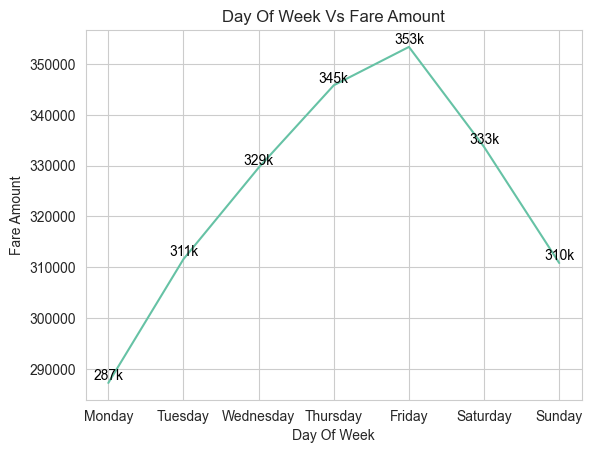

In [3]:
tab1 = df.groupby("Day_of_Week")["fare_amount"].sum().reset_index()
# tab1.sort_values(by="Day_of_Week", ascending = False)

days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
tab1["Day_of_Week"] = pd.Categorical(tab1["Day_of_Week"], categories= days_order , ordered = True)
tab1 = tab1.sort_values("Day_of_Week")
tab1

sns.set_style("whitegrid") # options: white, dark, darkgrid, whitegrid, ticks
sns.set_palette("pastel")    # set color palette
sns.set_palette("Set2")

ax = sns.lineplot( x = "Day_of_Week" , y = "fare_amount" ,errorbar=None , data = tab1 ,estimator = sum, legend= "auto")
x_vals, y_vals = ax.get_lines()[0].get_data()
for x, y in zip(x_vals, y_vals):
    ax.text(x, y, f"{int(y/1000)}k", ha='center', va='bottom', fontsize=10, color="black")
plt.title("Day Of Week Vs Fare Amount")
plt.xlabel("Day Of Week")
plt.ylabel("Fare Amount")
plt.plot()


In [4]:
df.drop(columns = ["Unnamed: 0.1",	"Unnamed: 0"],inplace = True)
df.head()

,Ride_Id,fare_amount,pickup_datetime,Day_of_Week,Year,Month,Day,Hour,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Distance
0,24238194,7.5,2015-05-07 19:52:06,Thursday,2015,5,7,19,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,27835199,7.7,2009-07-17 20:04:56,Friday,2009,7,17,20,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,44984355,12.9,2009-08-24 21:45:00,Monday,2009,8,24,21,-74.005043,40.740770,-73.962565,40.772647,1,0.053109
3,25894730,5.3,2009-06-26 08:22:21,Friday,2009,6,26,8,-73.976124,40.790844,-73.965316,40.803349,3,0.016528
4,17610152,16.0,2014-08-28 17:47:00,Thursday,2014,8,28,17,-73.925023,40.744085,-73.973082,40.761247,5,0.051031


[]

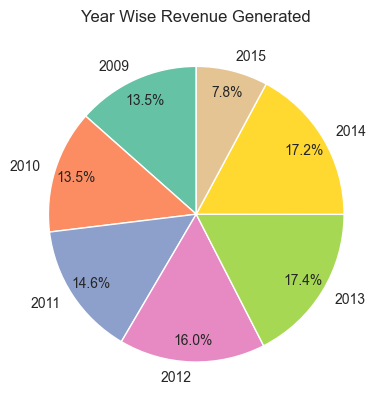

In [5]:
tab2 = df.groupby("Year")["fare_amount"].sum().reset_index()
tab2
# sns.set_style("whitegrid") # options: white, dark, darkgrid, whitegrid, ticks
# sns.set_palette("pastel")
# ax = sns.barplot(data = tab2 , x = "Year" , y = "fare_amount" )
# ax.bar_label(ax.containers[0])
# plt.plot()

plt.pie("fare_amount", data = tab2, labels ="Year", autopct='%1.1f%%',    # show percent with 1 decimal
        startangle=90,        # rotate start
        pctdistance=0.85)
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# plt.gca().add_artist(centre_circle)
plt.title("Year Wise Revenue Generated")
plt.plot()

[]

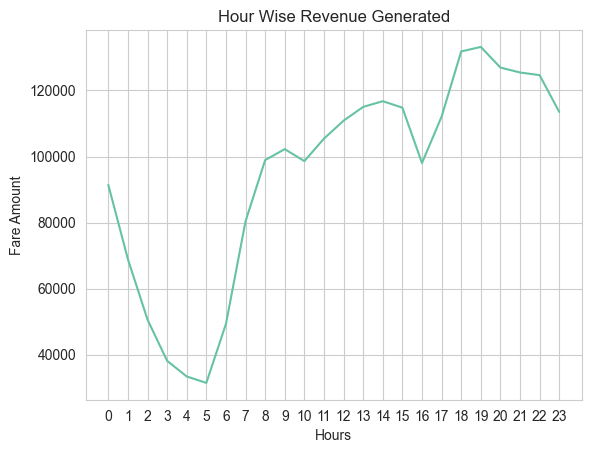

In [6]:
tab3 = df.groupby("Hour")["fare_amount"].sum().reset_index()
tab3
# plt.pie("fare_amount", data = tab3 , labels ="Hour", autopct='%1.1f%%',    # show percent with 1 decimal
#         startangle=90,        # rotate start
#         pctdistance=0.85)
# centre_circle = plt.Circle((0,0),0.70,fc='white')
# plt.gca().add_artist(centre_circle)
# plt.plot()
# plt.figlegend(True)
plt.fignum_exists(2)
ax = sns.lineplot(data = tab3 , x = "Hour" , y = "fare_amount" , errorbar = None)
plt.xlabel("Hours")
plt.ylabel("Fare Amount")
plt.xticks(range(0,24))
plt.title("Hour Wise Revenue Generated")
# ax.bar_label(ax.containers[0])
plt.plot()


In [7]:
# Total revenue generated for each passenger count 

temp = df.groupby("passenger_count")["fare_amount"].sum().reset_index()
temp


,passenger_count,fare_amount
0,0,6683.00
1,1,1557794.66
2,2,346783.44
3,3,102093.56
4,4,49769.51
5,5,157046.04
6,6,51929.11


[]

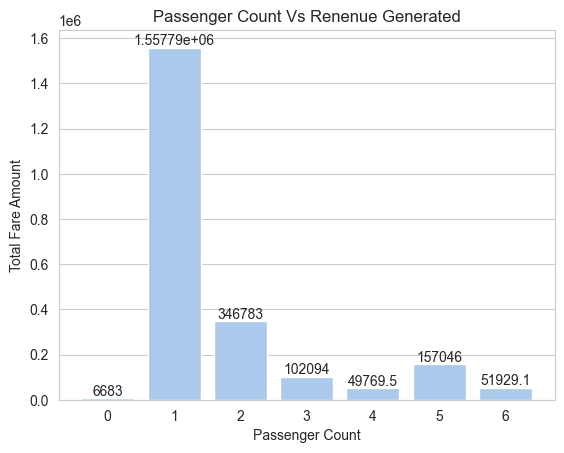

In [8]:
sns.set_style("whitegrid") # options: white, dark, darkgrid, whitegrid, ticks
sns.set_palette("pastel")    # set color palette
ax = sns.barplot(data=temp  , x= "passenger_count", y = "fare_amount")
ax.bar_label(ax.containers[0])
plt.title("Passenger Count Vs Renenue Generated")
plt.xlabel("Passenger Count")
plt.ylabel("Total Fare Amount")
plt.plot()


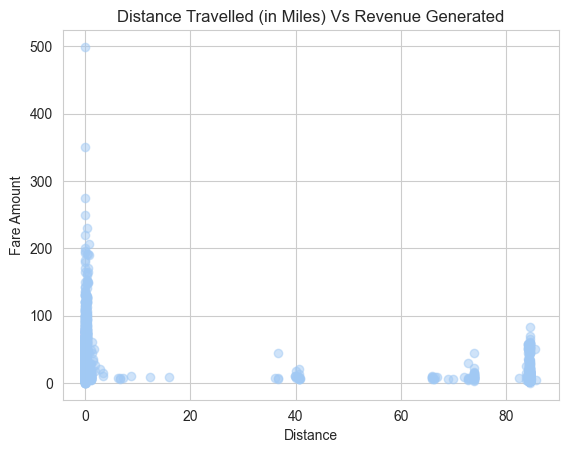

In [9]:
plt.scatter(data =df , x = "Distance" , y = "fare_amount" , alpha = 0.5)
# plt.xlim(0, 40)   # limit distance axis
# plt.ylim(0, 200)  # limit fare axis
# plt.xscale('log')
# plt.yscale('log')
plt.title("Distance Travelled (in Miles) Vs Revenue Generated")
plt.xlabel("Distance")
plt.ylabel("Fare Amount")
plt.show()

Base fare = $11.5

Even if the trip distance is 0 miles, the model predicts you’d pay about $11.35.

This captures the flag drop + extra surcharges (like minimum fare, tolls, etc.).

Rate per mile = $0.07 per mile

That’s very low compared to real taxi rates (NYC yellow cabs usually charge around $2–3 per mile).

This suggests:

Outliers or noise in the data (wrong coordinates, incorrect distances).

Or the regression is dominated by high base fares and weak distance correlation.



Base fare ≈ $11.26
Even if the trip distance is 0 miles, the model predicts you’d pay about $11.25.

This captures the flag drop + extra surcharges (like minimum fare, tolls, etc.).

Rate per mile ≈ $2.18

That matches real-world NYC taxi pricing (typically $2–3 per mile).

Meaning: for every extra mile, fare goes up by about $2.18.

Example predictions:

5 miles → 11.26+(2.18×5)= 22.16

10 miles → 11.26+(2.18×10)= 33.06

20 miles → 11.26+(2.18×20)= 55.86

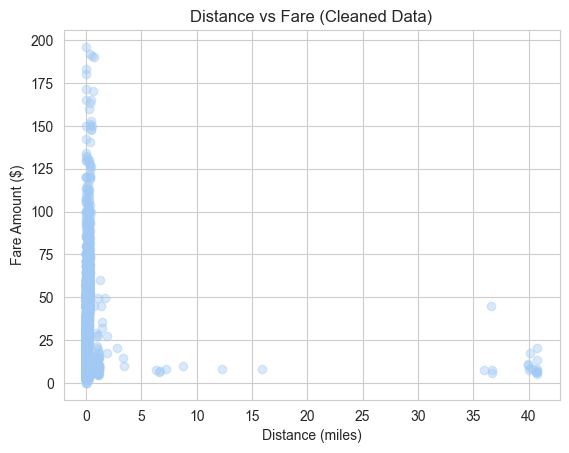

In [10]:
# Removing Outliers for the better predictions 

filtered = df[(df['Distance'] > 0) & (df['Distance'] < 50) & 
              (df['fare_amount'] > 0) & (df['fare_amount'] < 200)]

plt.scatter(filtered['Distance'], filtered['fare_amount'], alpha=0.4)
plt.xlabel("Distance (miles)")
plt.ylabel("Fare Amount ($)")
plt.title("Distance vs Fare (Cleaned Data)")
plt.show()


In [11]:

from sklearn.linear_model import LinearRegression

x = filtered[["Distance"]]
y = filtered["fare_amount"] 

model = LinearRegression()
model.fit(x,y)

print(model.intercept_)
print(model.coef_[0])


11.258001148505466
2.1815375027787973


In [12]:
avg_distance = df['Distance'].mean()
print("Average distance per ride:", avg_distance, "miles")


Average distance per ride: 0.20432436400111917 miles


In [55]:
trip_bins = pd.cut(df['Distance'], bins=[0, 2, 10, float('inf')],
                   labels=['Short (<2 mi)', 'Medium (2-10 mi)', 'Long (>10 mi)'])

trip_distribution = trip_bins.value_counts(normalize=True) * 100
print(trip_distribution)


Distance
Short (<2 mi)       99.779249
Long (>10 mi)        0.216634
Medium (2-10 mi)     0.004117
Name: proportion, dtype: float64


In [13]:
empty_passengers = df[df['passenger_count'] == 0]
anomalous_distances = df[df['Distance'] <= 0]
anomalous_fares = df[df['fare_amount'] <= 0]

print("Empty rides (0 passengers):", len(empty_passengers))
print("Invalid distance rides:", len(anomalous_distances))
print("Invalid fare rides:", len(anomalous_fares))

final = df[(df['Distance'] >= 0) & (df["passenger_count"]>0) & (df["fare_amount"]>0)]
print(final.count())
print(df.count())


Empty rides (0 passengers): 708
Invalid distance rides: 5632
Invalid fare rides: 5
Ride_Id              199256
fare_amount          199256
pickup_datetime      199256
Day_of_Week          199256
Year                 199256
Month                199256
Day                  199256
Hour                 199256
pickup_longitude     199256
pickup_latitude      199256
dropoff_longitude    199256
dropoff_latitude     199256
passenger_count      199256
Distance             199256
dtype: int64
Ride_Id              199969
fare_amount          199969
pickup_datetime      199969
Day_of_Week          199969
Year                 199969
Month                199969
Day                  199969
Hour                 199969
pickup_longitude     199969
pickup_latitude      199969
dropoff_longitude    199969
dropoff_latitude     199969
passenger_count      199969
Distance             199969
dtype: int64


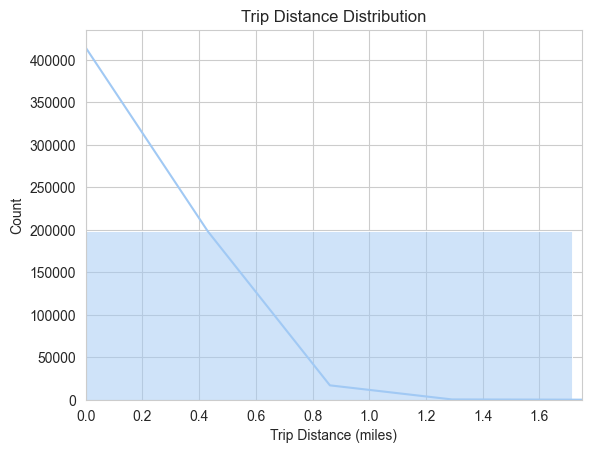

In [14]:
sns.histplot(final['Distance'], bins=50, kde=True)
plt.xlim(0,1.75)
plt.xlabel("Trip Distance (miles)")
plt.title("Trip Distance Distribution")
plt.show()


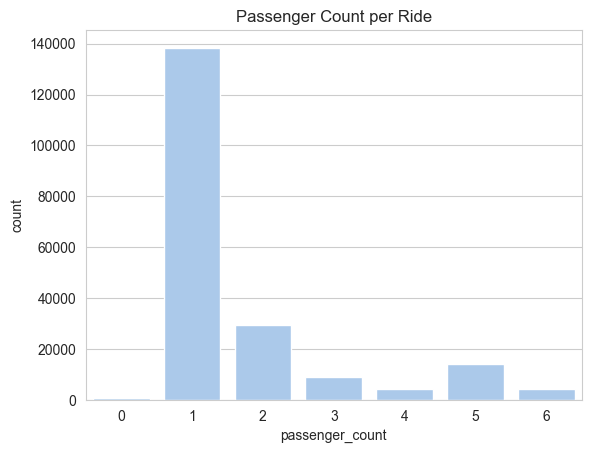

In [15]:

sns.countplot(x='passenger_count', data=df)
plt.title("Passenger Count per Ride")
plt.show()

In [28]:
# Fare Prediction Model Using Regression 

from sklearn.model_selection import train_test_split , GridSearchCV
from sklearn.preprocessing import OneHotEncoder , StandardScaler 
from sklearn.compose import ColumnTransformer 
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor 
from sklearn.metrics import mean_squared_error , r2_score , mean_absolute_error 
from sklearn.cluster import KMeans


In [24]:
df1.head(3)

,Ride_Id,fare_amount,pickup_datetime,Day_of_Week,Year,Month,Day,Hour,pickup_longitude,pickup_latitude,dropoff_longitude,dropoff_latitude,passenger_count,Distance
0,24238194,7.5,2015-05-07 19:52:06,Thursday,2015,5,7,19,-73.999817,40.738354,-73.999512,40.723217,1,0.015140
1,27835199,7.7,2009-07-17 20:04:56,Friday,2009,7,17,20,-73.994355,40.728225,-73.994710,40.750325,1,0.022103
2,44984355,12.9,2009-08-24 21:45:00,Monday,2009,8,24,21,-74.005043,40.740770,-73.962565,40.772647,1,0.053109


In [32]:
df1 = df.copy()

# df['Hour'] = df['pickup_datetime'].dt.hour
# df['Day_of_Week'] = df['pickup_datetime'].dt.day_name() 

df1["is_weekend"] = df1["Day_of_Week"].isin(['Saturday','Sunday']).astype(int)

co_ords = df1[["pickup_latitude","pickup_longitude"	]].dropna()

kmeans = KMeans(n_clusters = 12 , random_state = 42).fit(co_ords)

df1['pickup_zone'] = kmeans.predict(df1[["pickup_latitude","pickup_longitude"]])
# df1.head()

In [39]:
x = df1[['Distance','Hour','is_weekend','passenger_count','pickup_zone']]
y = df1["fare_amount"]

x_train, x_test , y_train , y_test = train_test_split( x , y , test_size = 0.2 , random_state = 42)

num_cols = ["Distance" , "Hour" , "passenger_count"]
cat_cols = ['pickup_zone','is_weekend'] 

preprocessor = ColumnTransformer([
     ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

pipeline = Pipeline([
    ('pre',preprocessor),
    ('model' , RandomForestRegressor(n_estimators=200, max_depth=12, random_state=42, n_jobs=-1))
])

pipeline.fit(x_train , y_train) 

preds = pipeline.predict(x_test)

mae = mean_absolute_error(y_test , preds)
rmse = r2_score(y_test , preds )

print(mae) 
print(rmse)


2.3172909820000958
0.7455956658144627
